In [ ]:
# Data Preprocessing -- Cleaning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector
import numpy as np
from dateutil import parser
import pandas as pd

class DataPreprocessing:
  def __init__(self, data):
    self.data = data

  def _dateTime_convert(self):
    self.data['policy_start_year'] = pd.to_datetime(train_data['Policy Start Date']).dt.date
    date_cleaned = self.data.drop("Policy Start Date",axis=1)
    date_cleaned['year'] = self.data['policy_start_year'].dt.year
    date_cleaned.head(20)

  def prepare_pipeline(self):
    #create X and y values
    self._dateTime_convert()
    X_data_cleaned = self.data.drop_duplicates()

    X_data_cleaned = X_data_cleaned.drop("Premium Amount",axis=1)
    y = X_data_cleaned['Premium Amount']

    cat_selector = make_column_selector(dtype_include=object)
    num_selector = make_column_selector(dtype_include=np.number)

    cat_selector(X_data_cleaned)
    num_selector(X_data_cleaned)


  # def drop_feature_and_target_columns(self, feature, target_col="Premium Amount"):
  #   self.data = self.data.drop(feature, axis=1)
  #   self.data = self.data.drop(target_col, axis=1)

  # def convert_categorical_to_numeric(self):
  #   categorical_features = self.data.select_dtypes(include="object").columns.tolist()

  #   ct = make_column_transformer(
  #       (StandardScaler(),['Length1','Length2','Length3','Height','Width']), #turn all values from 0 to 1
  #       (OneHotEncoder(handle_unknown="ignore"), ["Species"])
  #   )

  #   x_train, x_test, y_train, y_test = train_test_split(data_cleaned,y, test_size=0.2, random_state=42)
  #   print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
  #   X_train_normal = pd.DataFrame(ct.fit_transform(x_train))
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html#sphx-glr-auto-examples-ensemble-plot-stack-predictors-py

#     # If encoding methods like one-hot encoding (OHE) or label encoding are used, they should be done before splitting,
#     # as they don’t rely on the dataset distribution.
#     # If target encoding or mean encoding (which depend on target labels) is used,
#     # it must be done after splitting to avoid data leakage.
#     label_encoder = LabelEncoder()
#     for feature in categorical_features:
#         # label encoder
#       self.data[feature] = label_encoder.fit_transform(self.data[feature].values)
# # x_test['Species'] = label_encoder.transform(x_test['Species'].values)

# Referring code from
  # Policy start date: https://chatgpt.com/c/690f3499-8280-8330-8869-3af6bbca6980
  # https://towardsdatascience.com/regression-analysis-for-beginners-using-tree-based-methods-2b65bd193a7/
  # https://towardsdatascience.com/fish-weight-prediction-regression-analysis-for-beginners-part-1-8e43b0cb07e/

# https://nbviewer.org/urls/community.dataquest.io/uploads/short-url/66sbGpuYSKh15EWgmrQ9HeLWLBY.ipynb
# https://www.kaggle.com/code/nicolasgonzalezmunoz/ml-basics-data-transformations-and-pipelines
# More information reading: https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html#sphx-glr-auto-examples-ensemble-plot-stack-predictors-py

# https://community.dataquest.io/t/creating-a-pipeline-for-the-prediction-of-housing-prices-in-iowa/558254
# https://www.youtube.com/watch?v=OS2xRBNeNqM&t=1549s

# Cleaning data tutorial: https://www.youtube.com/watch?v=hnGuedS-Rss
# Linear Regression tutorial: https://www.youtube.com/watch?v=OTNR4rz3v8M&list=PLN-u2zr6UoV9ELCTv6n8310WJkZ-xwVi3&index=13
# Medical Insurance Price Prediction using Machine Learning - Python: https://www.geeksforgeeks.org/machine-learning/medical-insurance-price-prediction-using-machine-learning-python/
# Insurance Data~ Handing Missing Value(Cleaning): https://www.kaggle.com/code/prachi13/insurance-data-handing-missing-value-cleaning
# Insurance - EDA Univariate Bivariate and Baselines:  https://www.kaggle.com/code/aryagokh/insurance-eda-univariate-bivariate-and-baselines/notebook#Premium-Amount---The-OG-Target-Column
# Machine Learning Tutorial for Beginners: https://www.kaggle.com/code/kanncaa1/machine-learning-tutorial-for-beginners#CONCLUSION


In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# x_train, x_test, y_train, y_test = train_test_split(data_cleaned,y, test_size=0.2, random_state=42)
# print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


In [ ]:
from pandas.core.arrays import categorical
from numpy._core import numeric
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Class to load and read the data set.
class ReadDataSet:
  def __init__(self, directory_path: str):
    """Initialize with dataset path"""
    self.dir_path = directory_path
    self.df_train_data = None
    self.df_test_data = None
    self.df_sample_data = None
    # self.df = None

  # def read_dir(self):
  #     """Read directory to list all the csv files"""
  #     csv_files = [f for f in os.listdir(self.dir_path) if f.endswith("csv")]
  #     print("Available CSV files:")
  #     for i, file in enumerate(csv_files):
  #         print(f"{i}: {file}")
  #     return csv_files

  # def load_data(self):
  #     """Load dataset into a DataFrame"""
  #     csv_files_list = self.read_dir()
  #     # if csv_files_list:
  #     #     print("!!!!!!!! No Sample Data available .....")
  #     #     return

  #     choice = int(input("Enter the number of the file to read: "))
  #     file_path = os.path.join(self.dir_path, csv_files_list[choice])
  #     print(f"file read: {file_path}")
  #     self.df = pd.read_csv(file_path)
  #     print("✅ Dataset loaded successfully.")

  def load_train_data(self):
    """Load train dataset into a DataFrame"""
    train_data_file = "train.csv"
    file_path = os.path.join(self.dir_path, train_data_file)
    print(f"file read: {file_path}")
    self.df_train_data = pd.read_csv(file_path)
    print("✅ Train Dataset loaded successfully.")
    self.df_train_data = self.df_train_data.drop("id", axis=1)
    self.df_train_data.drop_duplicates(inplace=True)
    self.df_train_data = self._dateTime_convert(self.df_train_data)
    return self.df_train_data

  def load_test_data(self):
    """Load test dataset into a DataFrame"""
    train_data_file = "test.csv"
    file_path = os.path.join(self.dir_path, train_data_file)
    print(f"file read: {file_path}")
    self.df_test_data = pd.read_csv(file_path)
    print("✅ Test Dataset loaded successfully.")
    return self.df_test_data

  def load_sample_data(self):
    """Load sample dataset into a DataFrame"""
    sample_data_file = "sample_submission.csv"
    file_path = os.path.join(self.dir_path, sample_data_file)
    print(f"file read: {file_path}")
    self.df_sample_data = pd.read_csv(file_path)
    print("✅ Sample Dataset loaded successfully.")
    return self.df_sample_data

  def _dateTime_convert(self, data):
    data['policy_start_date'] = pd.to_datetime(data['Policy Start Date']).dt.date
    date_cleaned = data.drop("Policy Start Date",axis=1)
    # date_cleaned['year'] = data['policy_start_year'].dt.year
    date_cleaned.head(10)
    return date_cleaned

  def explore_features(self):
    """Check numeric and categorical features"""

    self.df_train_data.dropna(axis=0, inplace=True)
    # print("Get unique rows from the DataFrame:/n", self.df_train_data)
    print("size of dataframe after dropping duplictes", self.df_train_data.shape)

    print("\n📌 Columns:", self.df_train_data.columns.tolist())
    categorical_features = self.df_train_data.select_dtypes(include="object").columns.tolist()
    print("\n📌 Categorical Features:")
    print(categorical_features)

    # print(categorical_features.head())
    print("\n📌 Numeric Features:")
    numerical_features = self.df_train_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    print(numerical_features)
    # print(numeric_features.head())


  def plot_numeric_vs_target(self, target_col="Premium Amount"):
    """Scatter plot for numeric feature vs target"""
    numeric_features = self.df_train_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    numeric_features = [f for f in numeric_features if f != target_col]

    # sns.pairplot(self.df_train_data, vars = numeric_features, dropna = True, kind='scatter', plot_kws={'alpha': 0.4})

    for feature in numeric_features:
      plt.figure(figsize=(8,5))
      plt.scatter(self.df_train_data[feature], self.df_train_data[target_col], alpha=0.6, color="teal")
      plt.xlabel(feature)
      plt.ylabel(target_col)
      plt.title(f"{feature} vs {target_col}")
      plt.show()

  def feature_distribution(self, target_col="Premium Amount"):
    numeric_features = self.df_train_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    numeric_features = [f for f in numeric_features if f != target_col]

    for feature in numeric_features:
      sns.displot(
        data=self.df_train_data,
        x=target_col,
        hue=feature,
        kind="hist",
        height=6,
        aspect=1.4,
        bins=15
      )
      plt.show()

  def target_distribution(self, target_col="Premium Amount"):
    """Plot distribution of the target variable"""

    plt.figure(figsize=(8,5))
    plt.hist(self.df_train_data[target_col], bins=30, color="skyblue", edgecolor="black")
    plt.xlabel(target_col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {target_col}")
    plt.show()

  def plot_numeric_feature_distribution(self, target_col="Premium Amount"):
    """Plot distribution of a numeric feature"""

    numeric_features = self.df_train_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    numeric_features = [f for f in numeric_features if f != target_col]
    print(f"{numeric_features}")

    fig, axes = plt.subplots(len(numeric_features)//3, 3, figsize=(15, 6))
    i = 0
    for triaxis in axes:
      print(f"{triaxis}")
      for axis in triaxis:
        print(f"{axis}")
        print(f"{i} == {numeric_features[i]}")
        self.df_train_data.hist(column = numeric_features[i], ax=axis)
        i = i+1

    # for feature in numeric_features:
    #   plt.figure(figsize=(8,5))
    #   plt.hist(data_num[feature], bins=30, color="lightgreen", edgecolor="black")
    #   plt.xlabel(feature)
    #   plt.ylabel("Frequency")
    #   plt.title(f"Distribution of {feature}")
    #   plt.show()

  def correlation_with_target(self, target_col="Premium Amount"):
    """Show correlation of features with target variable"""

    correlation = self.df_train_data.corr(numeric_only=True)
    print("\n📌 Correlation with Target: f{target_col}")
    print(correlation[target_col].sort_values(ascending=False))

  def correlation_heatmap(self):
    """Heatmap of correlations"""

    # data_num = self.df_train_data.drop(columns=["id"])
    plt.figure(figsize=(10,6))
    corr = self.df_train_data.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap")
    plt.show()

  def plot_categorical_vs_target(self, target_col="Premium Amount"):
      """Boxplot for categorical feature vs target"""

      # categorical_features = self.df_train_data.select_dtypes(include="object").columns.tolist()
      for feature in categorical_features:
        print(f"\n📌 Plotting {feature} vs {target_col}...")
        sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")
        plt.xlabel(feature)
        plt.ylabel(target_col)
        plt.title(f"{feature} vs {target_col}")
        plt.show()

  def plot_SmokingStatus_vs_target(self, target_col="Premium Amount"):
      """Boxplot for categorical feature vs target"""
      # categorical_features = ['Smoking Status'] ['Exercise Frequency', 'Property Type', 'policy_start_date']
      # for feature in categorical_features:
      print(f"\n📌 Plotting 'Smoking Status' vs {target_col}...")
      sns.boxplot(x=self.df_train_data['Smoking Status'], y=self.df_train_data['Premium Amount'], palette="Set2")
      plt.xlabel("Smoking Status")
      plt.ylabel("Premium Amount")
      plt.title(f"{"Smoking Status"} vs {'Premium Amount'}")
      plt.show()



In [ ]:
dataSetClass = ReadDataSet("sample_data/Smart-premium-data-set")
# dataSetClass.load_data()
train_data = dataSetClass.load_train_data()
train_data.shape

file read: sample_data/Smart-premium-data-set/train.csv
✅ Train Dataset loaded successfully.


(1200000, 20)

In [ ]:
train_data.shape

(1200000, 20)

In [ ]:
train_data.describe()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,384004.000000,384004.000000,384004.000000,384004.000000,384004.000000,384004.000000,384004.000000,384004.000000,384004.000000
mean,41.139394,33072.900087,2.014088,25.580094,0.996247,9.561679,594.012820,5.020357,1113.187016
std,13.531632,32370.321642,1.415478,12.194086,0.978161,5.774009,149.607696,2.596525,868.688359
min,18.000000,2.000000,0.000000,2.024415,0.000000,0.000000,300.000000,1.000000,20.000000
25%,30.000000,8069.000000,1.000000,15.878551,0.000000,5.000000,470.000000,3.000000,519.000000
50%,41.000000,24182.000000,2.000000,24.579990,1.000000,10.000000,596.000000,5.000000,882.000000
75%,53.000000,44803.000000,3.000000,34.486417,2.000000,15.000000,722.000000,7.000000,1520.000000
max,64.000000,149997.000000,4.000000,58.452478,8.000000,19.000000,849.000000,9.000000,4997.000000


In [ ]:
train_data.head(10)


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
5,5,29.0,Male,45963.0,Married,1.0,Bachelor's,NaN,33.053198,Urban,...,2.0,4.0,614.0,5.0,2022-05-20 15:21:39.207847,Average,No,Weekly,House,3202.0
6,6,41.0,Male,40336.0,Married,0.0,PhD,NaN,NaN,Rural,...,2.0,8.0,807.0,6.0,2020-02-21 15:21:39.219432,Poor,No,Weekly,House,439.0
7,7,48.0,Female,127237.0,Divorced,2.0,High School,Employed,5.769783,Suburban,...,1.0,11.0,398.0,5.0,2022-08-08 15:21:39.181605,Average,No,Rarely,Condo,111.0
8,8,21.0,Male,1733.0,Divorced,3.0,Bachelor's,NaN,17.869551,Urban,...,1.0,10.0,685.0,8.0,2020-12-14 15:21:39.198406,Average,No,Monthly,Condo,213.0
9,9,44.0,Male,52447.0,Married,2.0,Master's,Employed,20.473718,Urban,...,1.0,9.0,635.0,3.0,2020-08-02 15:21:39.144722,Poor,No,Daily,Condo,64.0


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384004 entries, 0 to 1199990
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   384004 non-null  float64
 1   Gender                384004 non-null  object 
 2   Annual Income         384004 non-null  float64
 3   Marital Status        384004 non-null  object 
 4   Number of Dependents  384004 non-null  float64
 5   Education Level       384004 non-null  object 
 6   Occupation            384004 non-null  object 
 7   Health Score          384004 non-null  float64
 8   Location              384004 non-null  object 
 9   Policy Type           384004 non-null  object 
 10  Previous Claims       384004 non-null  float64
 11  Vehicle Age           384004 non-null  float64
 12  Credit Score          384004 non-null  float64
 13  Insurance Duration    384004 non-null  float64
 14  Policy Start Date     384004 non-null  object 
 15  Cust

In [ ]:
print("\n📌 Percentage of missing values:")
x = train_data.isna().sum()/train_data.shape[0] * 100
print(x[x > 0.0])  # missing values



📌 Percentage of missing values:
Age                      1.558750
Annual Income            3.745750
Marital Status           1.544083
Number of Dependents     9.139333
Occupation              29.839583
Health Score             6.173000
Previous Claims         30.335750
Vehicle Age              0.000500
Credit Score            11.490167
Insurance Duration       0.000083
Customer Feedback        6.485333
dtype: float64


In [ ]:
dataSetClass.explore_features()

size of dataframe after dropping duplictes (384004, 20)

📌 Columns: ['Age', 'Gender', 'Annual Income', 'Marital Status', 'Number of Dependents', 'Education Level', 'Occupation', 'Health Score', 'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'Premium Amount', 'policy_start_date']

📌 Categorical Features:
['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'policy_start_date']

📌 Numeric Features:
['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Premium Amount']


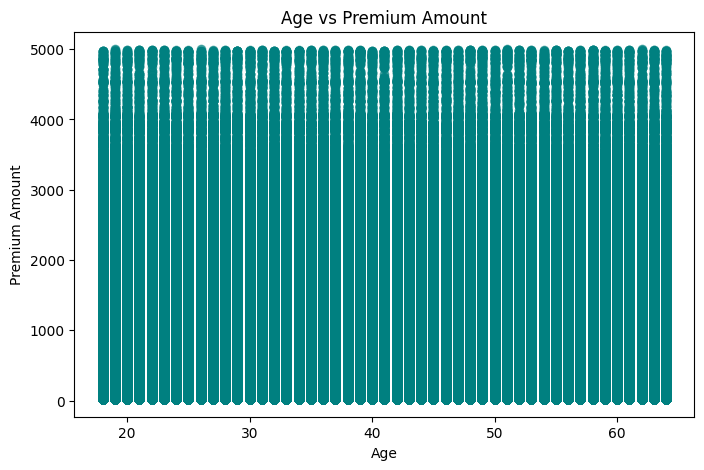

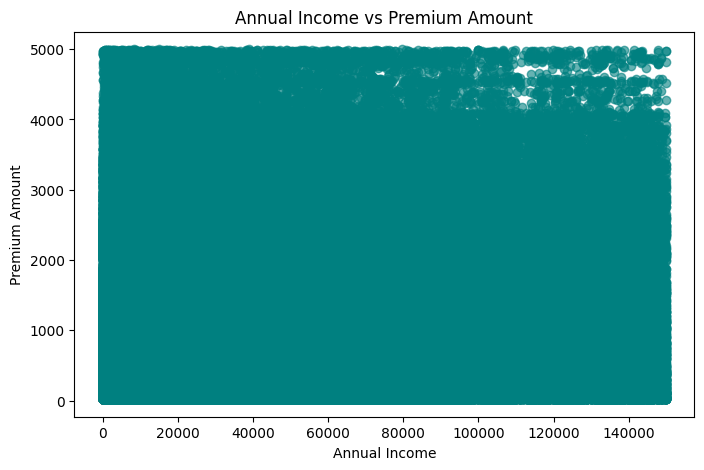

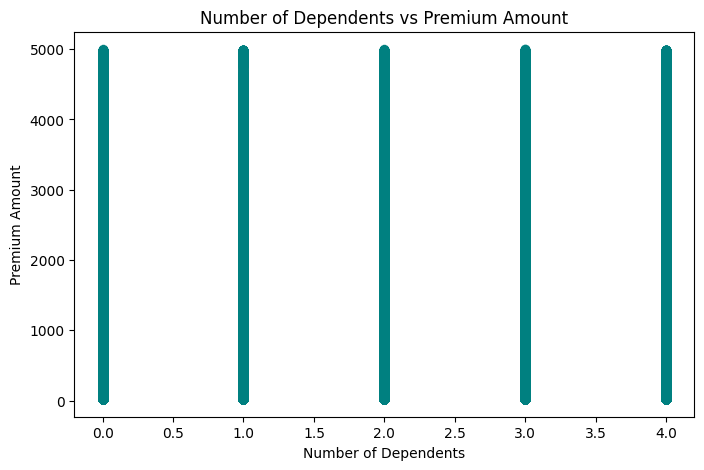

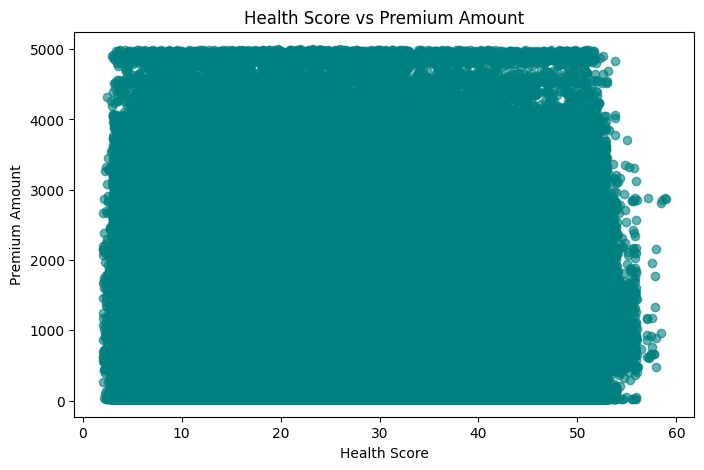

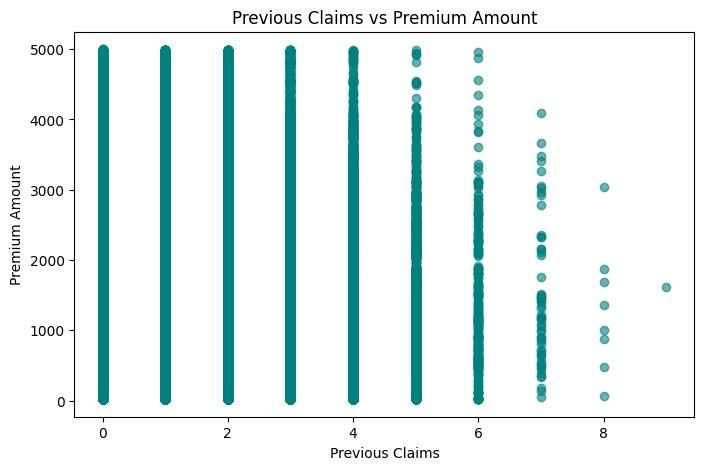

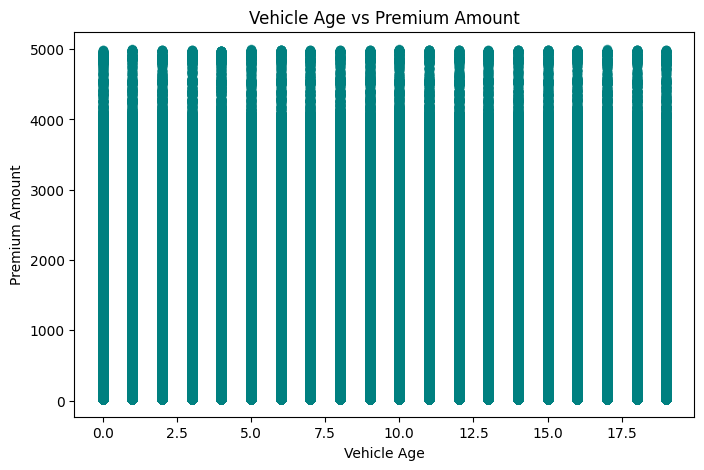

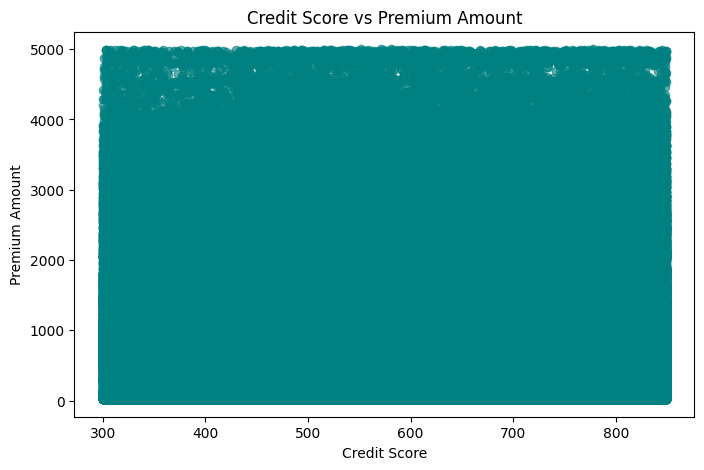

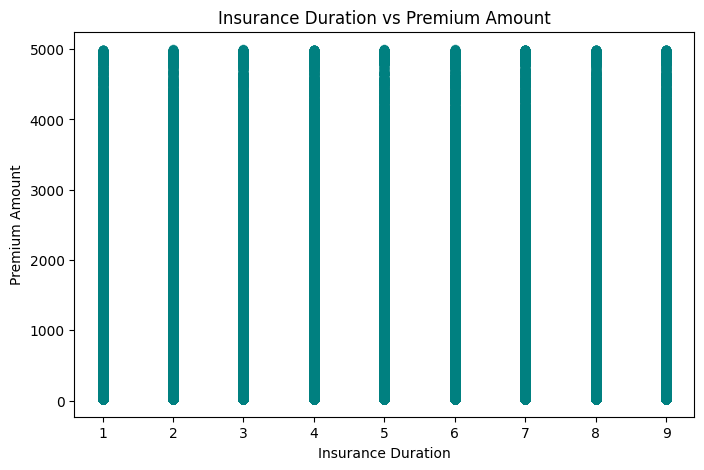

In [ ]:
dataSetClass.plot_numeric_vs_target()

In [ ]:
dataSetClass.correlation_with_target()


📌 Correlation with Target: f{target_col}
Premium Amount          1.000000
Previous Claims         0.046874
Health Score            0.014704
Vehicle Age             0.000391
Insurance Duration     -0.000028
Number of Dependents   -0.000976
Age                    -0.002430
Annual Income          -0.012390
Credit Score           -0.026014
Name: Premium Amount, dtype: float64


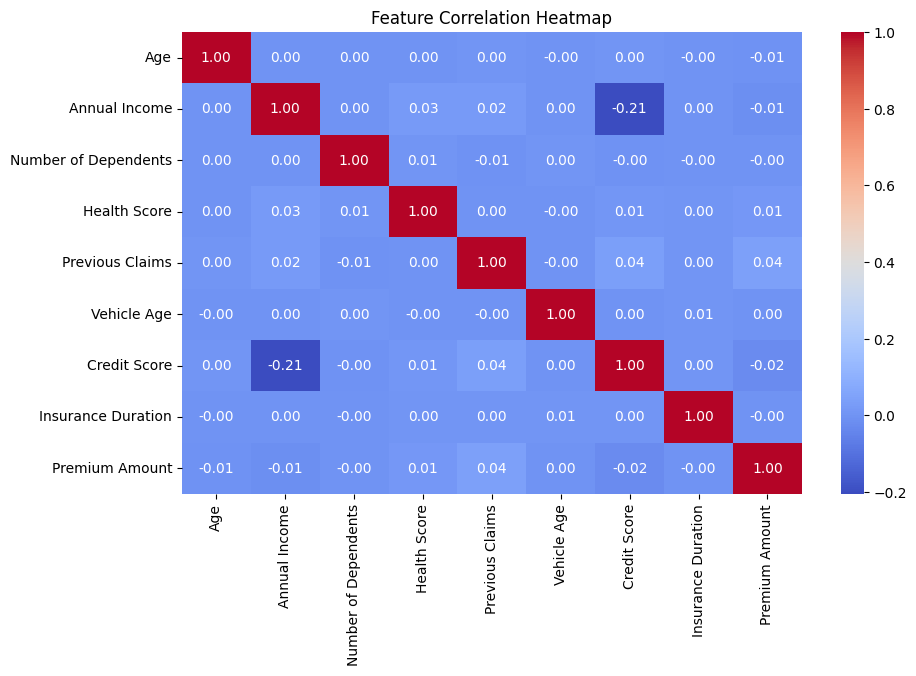

In [ ]:
dataSetClass.correlation_heatmap()


📌 Plotting Gender vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


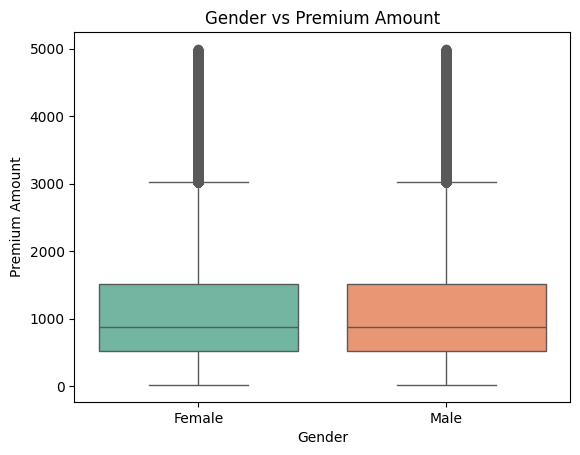


📌 Plotting Marital Status vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


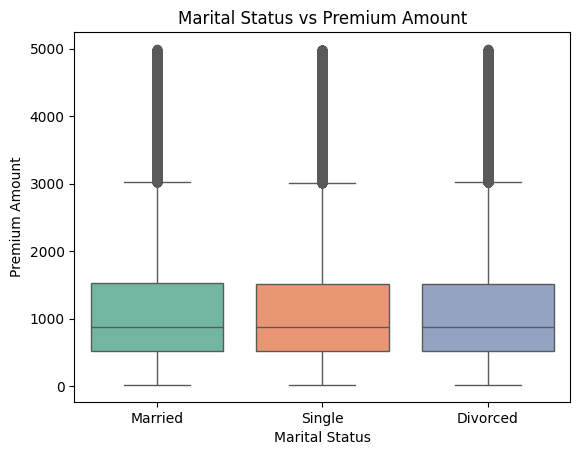


📌 Plotting Education Level vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


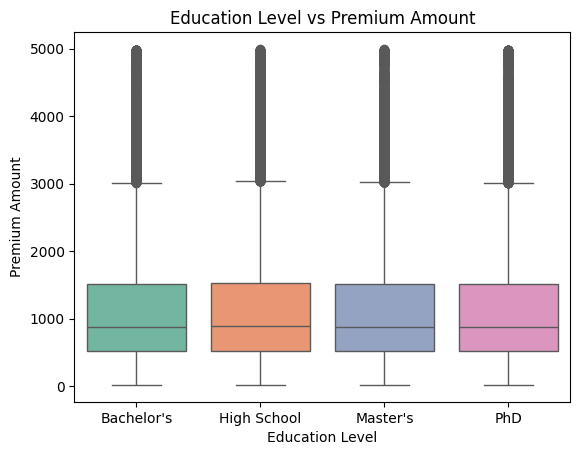


📌 Plotting Occupation vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


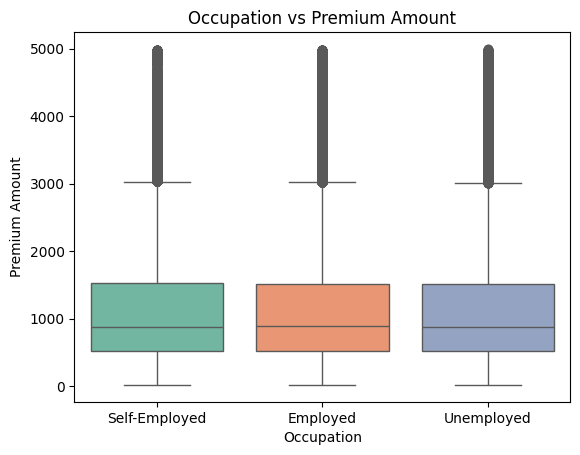


📌 Plotting Location vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


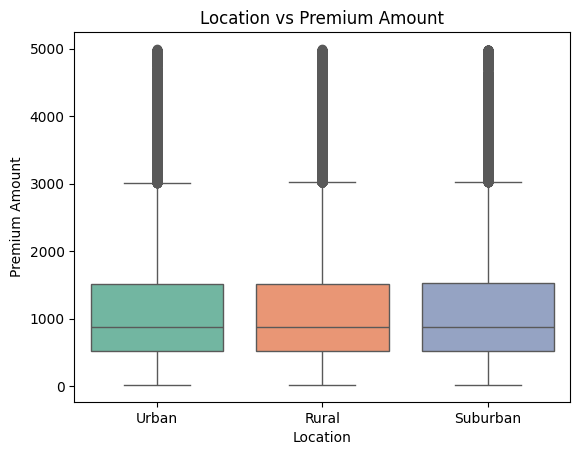


📌 Plotting Policy Type vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


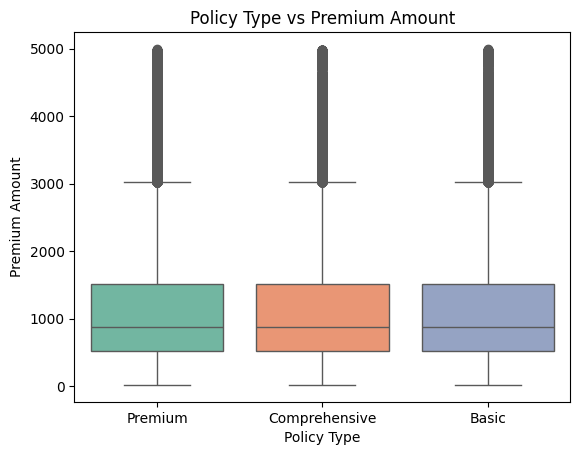


📌 Plotting Customer Feedback vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


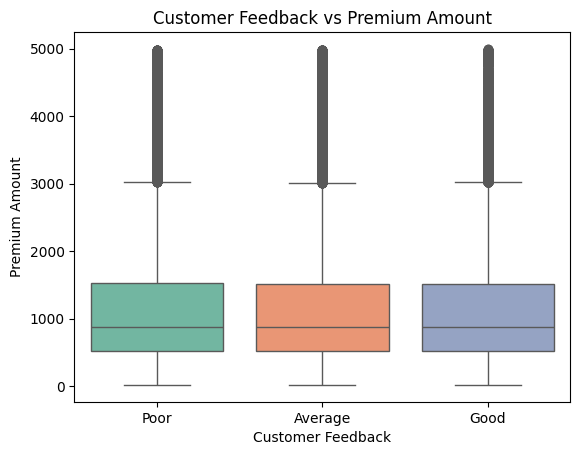


📌 Plotting Smoking Status vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


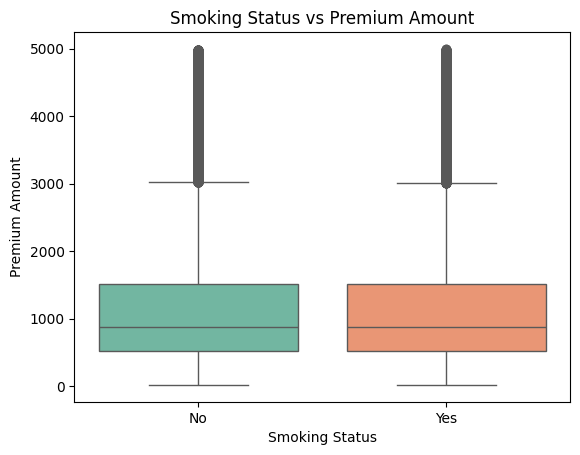


📌 Plotting Exercise Frequency vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


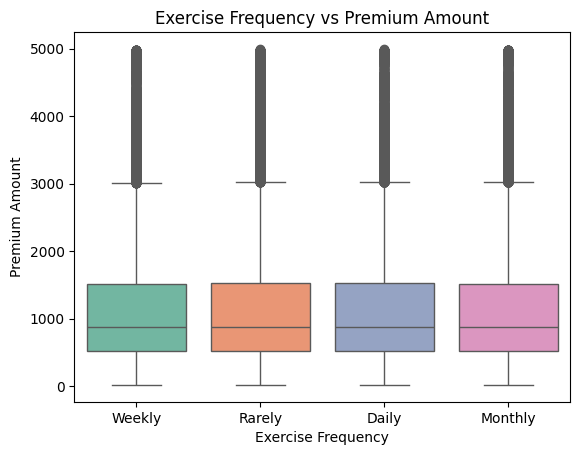


📌 Plotting Property Type vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


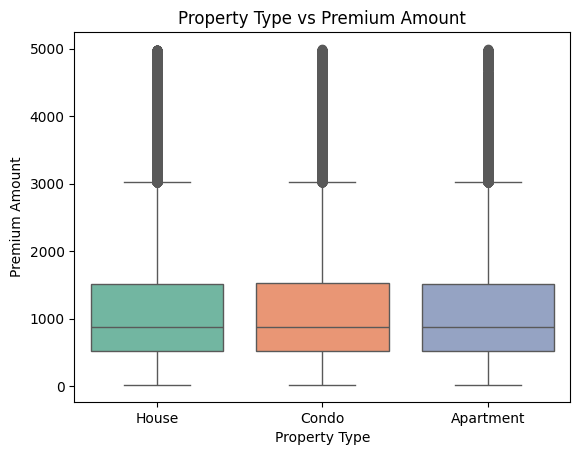


📌 Plotting policy_start_date vs Premium Amount...


/tmp/ipython-input-2699152260.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data[feature], y=self.df_train_data[target_col], palette="Set2")


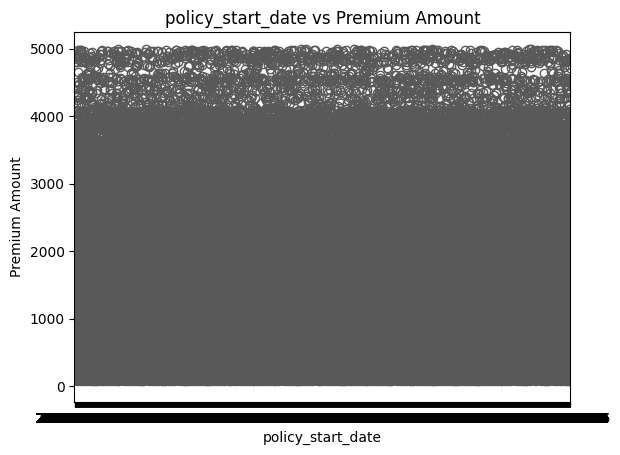

In [ ]:
dataSetClass.plot_categorical_vs_target()

In [ ]:
dataSetClass.target_distribution()

In [ ]:
dataSetClass.plot_numeric_feature_distribution()


📌 Plotting 'Smoking Status' vs Premium Amount...


/tmp/ipython-input-4046328949.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.df_train_data['Smoking Status'], y=self.df_train_data['Premium Amount'], palette="Set2")


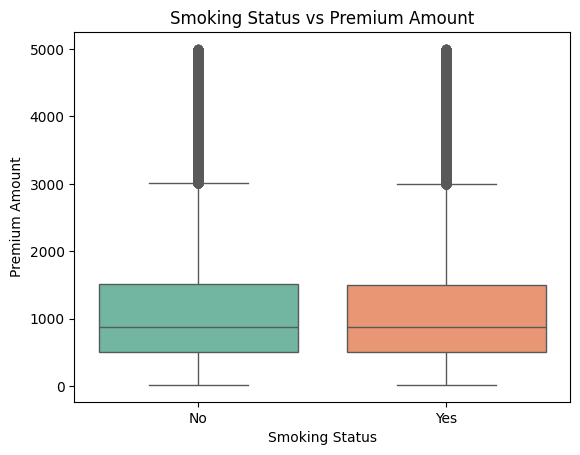

In [ ]:
dataSetClass.plot_SmokingStatus_vs_target()

In [ ]:
# https://github.com/harvey-allen/insurance-churn-classification/blob/main/Source%20Code.ipynb
# EDA for categorical data in insurance prediction

In [ ]:
dataSetClass.feature_distribution(train_data)

In [ ]:
pipeline_obj = DataPreprocessing(train_data)
# pipeline_obj.dateTime_convert()

In [ ]:

# policy = pd.DataFrame([['2023-12-23 15:21:39.134960'],['2023-06-12 15:21:39.111551']], columns=['Policy Start Date'] )
# policy

# from dateutil import parser
# def safe_parse_date(x):
#   if pd.isna(x): return pd.NaT
#   try: return pd.to_datetime(x)
#   except:
#       try: return parser.parse(str(x))
#       except: return pd.NaT

# tempDateTime = {}
# tempDateTime['policy_start_date'] = policy['Policy Start Date'].apply(safe_parse_date)
# policy['policy_start_year'] = tempDateTime['policy_start_date'].dt.year
# policy['policy_start_month'] = tempDateTime['policy_start_date'].dt.month

# policy = policy.drop("Policy Start Date",axis=1)
# policy


,policy_start_year,policy_start_month
0,2023,12
1,2023,6
